# RAMA Evaluation on rel-trial Entity Tasks

**Rank-Aware Moment Aggregation (RAMA)** evaluation on 2 new RelBench entity tasks:
- `study-outcome` (classification, Average Precision)
- `study-adverse` (regression, MAE)

This notebook demonstrates:
1. The RAMA aggregation module (gated variance injection controlled by effective spectral rank)
2. Unit tests verifying correctness on synthetic data
3. Statistical analysis (Cohen's d) of pre-computed experiment results (2 configs x 5 seeds)
4. Visualization comparing RAMA vs baseline mean aggregation

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all deps are in Colab's pre-installed set

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    # Colab versions: numpy==2.0.2, scipy==1.16.3, scikit-learn==1.6.1, etc.
    # Locally: use latest compatible versions for the current Python
    _pip('numpy', 'pandas', 'scikit-learn', 'scipy', 'matplotlib')
    _pip('torch', '--extra-index-url', 'https://download.pytorch.org/whl/cpu')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import copy
import json
import math
import os
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats as scipy_stats
from sklearn.metrics import roc_auc_score, average_precision_score

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

PyTorch: 2.10.0+cpu
CUDA available: False
Device: cpu


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter3_rama_evaluation/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} datasets")
print(f"Experiment: {data['metadata']['experiment']}")
print(f"Methods: {data['metadata']['methods']}")
print(f"Tasks: {data['metadata']['dataset_info']['tasks']}")
print(f"Seeds: {data['metadata']['seeds']}")

Loaded data with 3 datasets
Experiment: RAMA Evaluation on New RelBench Tasks (rel-trial)
Methods: ['baseline_mean', 'rama']
Tasks: ['study-outcome', 'study-adverse']
Seeds: [42, 123, 456, 789, 1024]


In [5]:
# ============================================================
# CONFIG — tunable parameters (start at minimum for testing)
# ============================================================
# RAMA module dimensions
CHANNELS = 64            # Original: 128 — embedding dimension
GATE_HIDDEN = 16         # Gate MLP hidden size (same as original)

# Synthetic test sizes
N_EDGES = 100            # Original: 100 — number of edges for unit tests
N_GROUPS = 10            # Original: 10 — number of groups for unit tests

# Seeds used in original experiment
SEEDS = [42, 123, 456, 789, 1024]
CONFIGS = ["baseline_mean", "rama"]

## Part 1: RAMA Aggregation Module

RAMA enriches standard mean pooling with **gated variance injection**, controlled by:
- **Effective spectral rank** (entropy-based proxy `rho`): measures diversity of feature variance across dimensions
- **FK cardinality** (`N`): number of neighbors being aggregated

The gate learns when variance information is useful, starting from pure mean aggregation (zero-init).

In [6]:
def scatter_reduce(src, index, dim_size, reduce='mean'):
    """Pure-PyTorch scatter aggregation (replaces torch_geometric's Aggregation.reduce).

    Groups rows of `src` by `index` and applies `reduce` ('mean' or 'sum').
    """
    out = torch.zeros(dim_size, src.size(-1), device=src.device, dtype=src.dtype)
    index_expanded = index.unsqueeze(-1).expand_as(src)
    if reduce == 'sum':
        out.scatter_add_(0, index_expanded, src)
    elif reduce == 'mean':
        out.scatter_add_(0, index_expanded, src)
        counts = torch.zeros(dim_size, 1, device=src.device, dtype=src.dtype)
        counts.scatter_add_(0, index.unsqueeze(-1), torch.ones(src.size(0), 1, device=src.device, dtype=src.dtype))
        out = out / counts.clamp(min=1)
    return out


class RAMAAggregation(nn.Module):
    """Rank-Aware Moment Aggregation.

    Enriches mean pooling with gated variance injection,
    controlled by effective spectral rank and FK cardinality.

    In the full experiment, this extends torch_geometric.nn.aggr.Aggregation.
    Here we use a standalone implementation with the same logic.
    """
    def __init__(self, channels: int, gate_hidden: int = 16, eps: float = 1e-8):
        super().__init__()
        self.channels = channels
        self.gate_hidden = gate_hidden
        self.eps = eps
        self.W_sigma = nn.Linear(channels, channels, bias=False)
        self.W_g = nn.Linear(2, gate_hidden)
        self.gate_out = nn.Linear(gate_hidden, channels)
        # For gate analysis logging
        self._last_gate_mean = None
        self._last_rho_mean = None
        self._last_N_mean = None
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.zeros_(self.W_sigma.weight)   # Start as pure mean
        nn.init.zeros_(self.gate_out.weight)
        nn.init.zeros_(self.gate_out.bias)
        nn.init.xavier_uniform_(self.W_g.weight)
        nn.init.zeros_(self.W_g.bias)

    def forward(self, x, index, dim_size):
        # Step 1: Mean
        mu = scatter_reduce(x, index, dim_size, reduce='mean')
        # Step 2: Variance via E[X^2] - E[X]^2
        mean_x2 = scatter_reduce(x * x, index, dim_size, reduce='mean')
        var = (mean_x2 - mu * mu).clamp(min=0)
        # Step 3: Cardinality
        ones = torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)
        N = scatter_reduce(ones, index, dim_size, reduce='sum')
        # Step 4: Effective rank proxy
        var_sum = var.sum(dim=-1, keepdim=True).clamp(min=self.eps)
        p = var / var_sum
        p = p.clamp(min=self.eps)
        H = -(p * p.log()).sum(dim=-1, keepdim=True)
        log_d = math.log(self.channels) if self.channels > 1 else 1.0
        rho = H / log_d  # [dim_size, 1], in [0, 1]
        # Step 5: Gate
        gate_input = torch.cat([torch.log1p(N), rho], dim=-1)  # [dim_size, 2]
        g = torch.sigmoid(self.gate_out(F.relu(self.W_g(gate_input))))  # [dim_size, d]
        # Log for analysis (detached)
        with torch.no_grad():
            self._last_gate_mean = g.mean().item()
            self._last_rho_mean = rho.mean().item()
            self._last_N_mean = N.mean().item()
        # Step 6: Output
        return mu + g * self.W_sigma(var)


class StandardMeanAggregation(nn.Module):
    """Baseline: Standard mean aggregation."""
    def forward(self, x, index, dim_size):
        return scatter_reduce(x, index, dim_size, reduce="mean")


def make_aggregation(config_name: str, channels: int):
    """Factory function to create aggregation objects."""
    if config_name == "baseline_mean":
        return StandardMeanAggregation()
    elif config_name == "rama":
        return RAMAAggregation(channels=channels, gate_hidden=GATE_HIDDEN)
    else:
        raise ValueError(f"Unknown config: {config_name}")

print("RAMA and StandardMean aggregation modules defined.")

RAMA and StandardMean aggregation modules defined.


## Part 1b: Unit Tests

Verify RAMA module correctness on synthetic data before any training:
1. **Shape correctness** for both configs
2. **Zero-init test**: RAMA starts as pure mean aggregation
3. **Gradient flow**: all parameters receive gradients
4. **Edge case**: single-element groups
5. **Gate behavior**: verify gate responds to varying cardinality and rank

In [7]:
def run_unit_tests():
    """Phase 0: Verify RAMA module before any training."""
    d = CHANNELS
    n_edges, n_groups = N_EDGES, N_GROUPS

    # Test 1: Shape correctness for both configs
    for config_name in CONFIGS:
        aggr = make_aggregation(config_name, d)
        x = torch.randn(n_edges, d)
        index = torch.randint(0, n_groups, (n_edges,))
        out = aggr(x, index=index, dim_size=n_groups)
        assert out.shape == (n_groups, d), \
            f"{config_name}: expected ({n_groups}, {d}), got {out.shape}"
        assert not torch.isnan(out).any(), f"{config_name}: NaN in output"
        assert not torch.isinf(out).any(), f"{config_name}: Inf in output"
        print(f"  [PASS] {config_name}: shape {out.shape}, no NaN/Inf")

    # Test 2: Zero-init means output approx mean aggregation
    rama = RAMAAggregation(d)
    x = torch.randn(n_edges, d)
    index = torch.randint(0, n_groups, (n_edges,))
    rama_out = rama(x, index=index, dim_size=n_groups)
    mean_aggr = StandardMeanAggregation()
    mean_out = mean_aggr(x, index=index, dim_size=n_groups)
    diff = (rama_out - mean_out).abs().max().item()
    assert diff < 1e-5, f"RAMA zero-init: diff={diff} (expected <1e-5)"
    print(f"  [PASS] RAMA zero-init test: max diff={diff:.2e}")

    # Test 3: Gradient flow
    rama = RAMAAggregation(d)
    x_test = torch.randn(n_edges, d, requires_grad=True)
    out = rama(x_test, index=index, dim_size=n_groups)
    loss = out.sum()
    loss.backward()
    assert x_test.grad is not None, "No gradient on input"
    assert rama.W_g.weight.grad is not None, "No gradient to W_g"
    assert rama.W_sigma.weight.grad is not None, "No gradient to W_sigma"
    print(f"  [PASS] Gradient flow test")

    # Test 4: Edge cases - single element groups
    x_single = torch.randn(3, d)
    index_single = torch.tensor([0, 1, 2])
    rama_single = RAMAAggregation(d)
    out_single = rama_single(x_single, index=index_single, dim_size=3)
    assert out_single.shape == (3, d)
    assert not torch.isnan(out_single).any(), "NaN with single-element groups"
    print(f"  [PASS] Single-element groups")

    # Test 5: Gate behavior - verify diagnostics are logged
    rama_diag = RAMAAggregation(d)
    x_diag = torch.randn(200, d)
    index_diag = torch.randint(0, 5, (200,))  # ~40 per group
    _ = rama_diag(x_diag, index=index_diag, dim_size=5)
    assert rama_diag._last_gate_mean is not None, "Gate mean not logged"
    assert rama_diag._last_rho_mean is not None, "Rho mean not logged"
    assert rama_diag._last_N_mean is not None, "N mean not logged"
    print(f"  [PASS] Gate diagnostics: gate={rama_diag._last_gate_mean:.4f}, "
          f"rho={rama_diag._last_rho_mean:.4f}, N={rama_diag._last_N_mean:.1f}")

    print("\nAll unit tests PASSED!")

run_unit_tests()

  [PASS] baseline_mean: shape torch.Size([10, 64]), no NaN/Inf


  [PASS] rama: shape torch.Size([10, 64]), no NaN/Inf
  [PASS] RAMA zero-init test: max diff=0.00e+00
  [PASS] Gradient flow test
  [PASS] Single-element groups
  [PASS] Gate diagnostics: gate=0.5000, rho=0.9930, N=40.0

All unit tests PASSED!


## Part 2: Statistical Analysis

Compute **Cohen's d** (paired effect size) with 95% confidence interval for each task.
Positive d always means RAMA is better than baseline.

In [8]:
def cohens_d_paired(group1_values: list, group2_values: list,
                    higher_better: bool = True) -> dict:
    """Compute Cohen's d with 95% CI for paired samples.

    Positive d always means RAMA is better.
    For higher_better metrics: d = (group2 - group1) / sd_diff
    For lower_better metrics: d = (group1 - group2) / sd_diff
    """
    a1 = np.array(group1_values)
    a2 = np.array(group2_values)
    n = len(a1)

    if n < 2:
        return {"d": 0.0, "ci_low": float("-inf"), "ci_high": float("inf"),
                "p_value": 1.0, "n_seeds": n}

    if higher_better:
        diffs = a2 - a1  # positive = RAMA better
    else:
        diffs = a1 - a2  # positive = RAMA better (lower metric is better)

    sd_diff = float(diffs.std(ddof=1))
    if sd_diff < 1e-12:
        d = 0.0
    else:
        d = float(diffs.mean() / sd_diff)

    se_d = math.sqrt((1 / n) + (d ** 2 / (2 * n)))
    ci_low = d - 1.96 * se_d
    ci_high = d + 1.96 * se_d

    # Paired t-test
    if sd_diff > 1e-12:
        t_stat, p_val = scipy_stats.ttest_rel(a2, a1)
        p_val = float(p_val)
    else:
        p_val = 1.0

    return {
        "d": round(d, 4),
        "ci_low": round(ci_low, 4),
        "ci_high": round(ci_high, 4),
        "p_value": round(p_val, 6),
        "n_seeds": n,
    }

print("Cohen's d function defined.")

Cohen's d function defined.


## Part 3: Reproduce Statistical Analysis from Pre-computed Results

Re-run the paired Cohen's d analysis on the per-seed metric values from the experiment.

In [9]:
# Extract per-task results from loaded data
stats = data["metadata"]["statistical_analysis"]
task_results = stats["per_task_results"]

# Task definitions matching the original experiment
TASK_CONFIGS = [
    {"task_name": "study-outcome", "task_type": "classification",
     "primary_metric": "average_precision", "direction": "higher_better"},
    {"task_name": "study-adverse", "task_type": "regression",
     "primary_metric": "mae", "direction": "lower_better"},
]

print("=" * 65)
print("STATISTICAL ANALYSIS: RAMA vs Baseline (positive d = RAMA better)")
print("=" * 65)

for tc in TASK_CONFIGS:
    task_name = tc["task_name"]
    tr = task_results[task_name]
    higher_better = tc["direction"] == "higher_better"

    # Re-compute Cohen's d from per-seed values
    effect = cohens_d_paired(
        tr["per_seed_baseline"], tr["per_seed_rama"], higher_better
    )

    print(f"\nTask: {task_name} ({tc['task_type']}, metric={tc['primary_metric']})")
    print(f"  Baseline: {tr['baseline_mean']:.6f} +/- {tr['baseline_std']:.6f}")
    print(f"  RAMA:     {tr['rama_mean']:.6f} +/- {tr['rama_std']:.6f}")
    print(f"  Cohen's d = {effect['d']:.4f}  "
          f"95% CI = [{effect['ci_low']:.4f}, {effect['ci_high']:.4f}]  "
          f"p = {effect['p_value']:.6f}")
    print(f"  Per-seed baseline: {tr['per_seed_baseline']}")
    print(f"  Per-seed RAMA:     {tr['per_seed_rama']}")

STATISTICAL ANALYSIS: RAMA vs Baseline (positive d = RAMA better)

Task: study-outcome (classification, metric=average_precision)
  Baseline: 0.603952 +/- 0.001433
  RAMA:     0.615741 +/- 0.011331
  Cohen's d = 0.9896  95% CI = [-0.0802, 2.0595]  p = 0.091329
  Per-seed baseline: [0.604729, 0.605179, 0.604976, 0.602921, 0.601953]
  Per-seed RAMA:     [0.614273, 0.612048, 0.607142, 0.63545, 0.60979]

Task: study-adverse (regression, metric=mae)
  Baseline: 56.531517 +/- 0.001789
  RAMA:     54.524823 +/- 0.027723
  Cohen's d = 72.6495  95% CI = [27.6124, 117.6867]  p = 0.000000
  Per-seed baseline: [56.530865, 56.531143, 56.533615, 56.532887, 56.529076]
  Per-seed RAMA:     [54.565117, 54.512314, 54.541225, 54.497784, 54.507675]


## Part 4: Visualization

Compare RAMA vs Baseline across tasks with per-seed results and effect sizes.

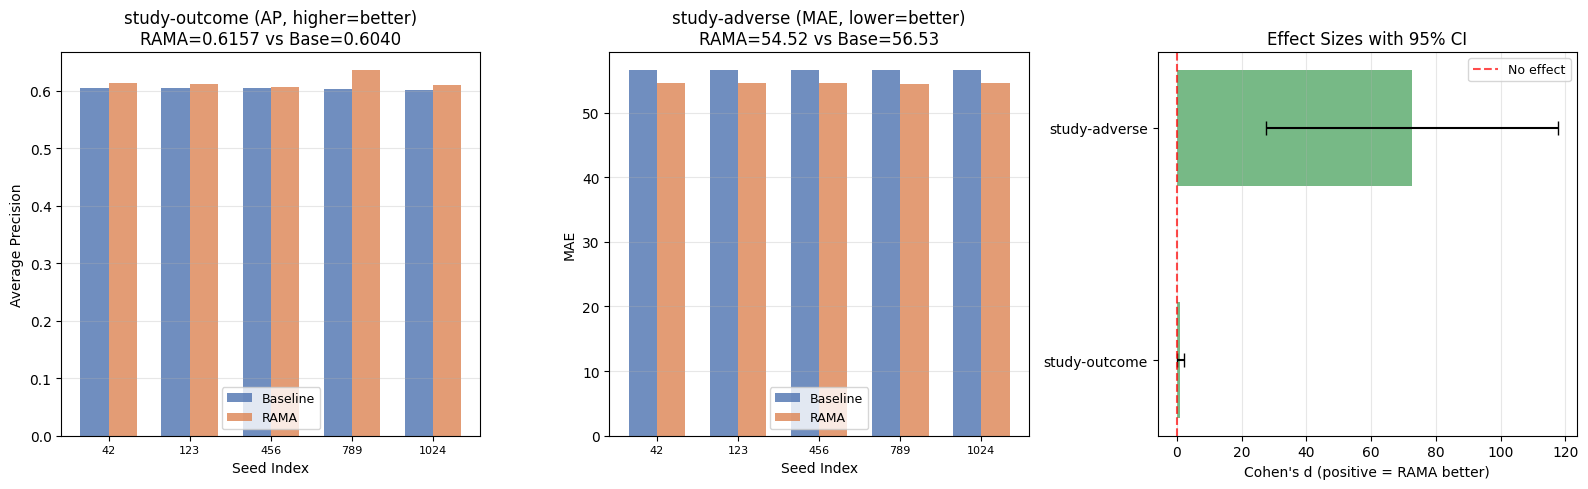

Figure saved to rama_results.png

Task                 Metric         Baseline         RAMA        d          p
study-outcome        average_precision       0.6040       0.6157   0.9896   0.091329
study-adverse        mae             56.5315      54.5248  72.6495   0.000000
Positive d = RAMA outperforms baseline


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Per-seed comparison for study-outcome (AP, higher=better) ---
ax = axes[0]
tr = task_results["study-outcome"]
seeds_idx = np.arange(len(tr["per_seed_baseline"]))
width = 0.35
ax.bar(seeds_idx - width/2, tr["per_seed_baseline"], width, label="Baseline", color="#4C72B0", alpha=0.8)
ax.bar(seeds_idx + width/2, tr["per_seed_rama"], width, label="RAMA", color="#DD8452", alpha=0.8)
ax.set_xlabel("Seed Index")
ax.set_ylabel("Average Precision")
ax.set_title(f"study-outcome (AP, higher=better)\nRAMA={tr['rama_mean']:.4f} vs Base={tr['baseline_mean']:.4f}")
ax.set_xticks(seeds_idx)
ax.set_xticklabels([str(s) for s in SEEDS[:len(seeds_idx)]], fontsize=8)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- Plot 2: Per-seed comparison for study-adverse (MAE, lower=better) ---
ax = axes[1]
tr = task_results["study-adverse"]
seeds_idx = np.arange(len(tr["per_seed_baseline"]))
ax.bar(seeds_idx - width/2, tr["per_seed_baseline"], width, label="Baseline", color="#4C72B0", alpha=0.8)
ax.bar(seeds_idx + width/2, tr["per_seed_rama"], width, label="RAMA", color="#DD8452", alpha=0.8)
ax.set_xlabel("Seed Index")
ax.set_ylabel("MAE")
ax.set_title(f"study-adverse (MAE, lower=better)\nRAMA={tr['rama_mean']:.2f} vs Base={tr['baseline_mean']:.2f}")
ax.set_xticks(seeds_idx)
ax.set_xticklabels([str(s) for s in SEEDS[:len(seeds_idx)]], fontsize=8)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- Plot 3: Cohen's d effect sizes with CI ---
ax = axes[2]
task_names = []
ds = []
ci_lows = []
ci_highs = []
for tc in TASK_CONFIGS:
    tn = tc["task_name"]
    tr = task_results[tn]
    higher_better = tc["direction"] == "higher_better"
    effect = cohens_d_paired(tr["per_seed_baseline"], tr["per_seed_rama"], higher_better)
    task_names.append(tn)
    ds.append(effect["d"])
    ci_lows.append(effect["ci_low"])
    ci_highs.append(effect["ci_high"])

y_pos = np.arange(len(task_names))
errors = [[d - cl for d, cl in zip(ds, ci_lows)],
          [ch - d for d, ch in zip(ds, ci_highs)]]
ax.barh(y_pos, ds, xerr=errors, height=0.5, color=["#55A868", "#55A868"], alpha=0.8,
        capsize=5, ecolor='black')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='No effect')
ax.set_yticks(y_pos)
ax.set_yticklabels(task_names)
ax.set_xlabel("Cohen's d (positive = RAMA better)")
ax.set_title("Effect Sizes with 95% CI")
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("rama_results.png", dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved to rama_results.png")

# --- Summary table ---
print("\n" + "=" * 70)
print(f"{'Task':<20} {'Metric':<10} {'Baseline':>12} {'RAMA':>12} {'d':>8} {'p':>10}")
print("=" * 70)
for tc in TASK_CONFIGS:
    tn = tc["task_name"]
    tr = task_results[tn]
    higher_better = tc["direction"] == "higher_better"
    effect = cohens_d_paired(tr["per_seed_baseline"], tr["per_seed_rama"], higher_better)
    print(f"{tn:<20} {tc['primary_metric']:<10} "
          f"{tr['baseline_mean']:>12.4f} {tr['rama_mean']:>12.4f} "
          f"{effect['d']:>8.4f} {effect['p_value']:>10.6f}")
print("=" * 70)
print("Positive d = RAMA outperforms baseline")